# **MODEL**

In this notebook, we will create the baseline model with no physics-informed loss function and a PINN with the modified loss function to account for the physics. We start off with our usual imports,

In [10]:
# PyTorch imports,
import torch # <-- PyTorch
from torch.nn import Linear
from torch.utils.data import Dataset, DataLoader # <-- Wrappers for the data.
from torch.optim import Adam
import torch.nn.functional as F
import torchvision
from torchinfo import summary

# Importing,
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

# Printing versions,
print("System Version:", sys.version)
print("PyTorch version", torch.__version__)
print("Torch Vision version", torchvision.__version__)
print("Numpy version", np.__version__)
print("Pandas version", pd.__version__)

System Version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
PyTorch version 2.6.0+cpu
Torch Vision version 0.21.0+cpu
Numpy version 1.26.4
Pandas version 2.2.2


### 1. Loading Data

In [85]:
class FlowDataset(Dataset):
    """Class container for the training data."""

    def __init__(self, split="train"):
        """Loads, scales (using min-max) and converts the data into Tensors."""

        # Loading,
        if split == "test":
            Xy = np.load("data_train.npy")
        elif split == "validation":
            Xy = np.load("validation_train.npy")
        else:
            Xy = np.load("data_train.npy")

        self.n_samples = Xy.shape[1]
        self.X, self.y = Xy[0], Xy[1]

        # Performing min-max scaling,
        self.X_min, self.X_max  = np.min(self.X), np.max(self.X)
        self.y_min, self.y_max  = np.min(self.y), np.max(self.y)
        self.X = (self.X - self.X_max)/(self.X_max - self.X_min)
        self.y = (self.y - self.y_max)/(self.y_max - self.y_min)

        # Converting to Tensors (float32 type),
        self.X = torch.from_numpy(self.X.astype(np.float32))
        self.y = torch.from_numpy(self.y.astype(np.float32))

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
    def __len__(self):
        return self.n_samples

# Loading training, testing and validation data,
train_data = FlowDataset("train")
test_data = FlowDataset("train")
val_data = FlowDataset("train")

# Creating dataloaders,
BATCH_SIZE = 128
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset=val_data, batch_size=BATCH_SIZE, shuffle=True)

Inspecting the data,

In [86]:
for (X, y) in train_loader:
    print(f"X: {X.shape}, y: {y.shape}")
    break

X: torch.Size([128, 3]), y: torch.Size([128, 3])


### 2. Model Creation

In this section we create the model architecture for the PINN. There is nothing too special about the architecture of vanilla PINNs, they are mid-sized (maybe towards the smaller end) MLPS. The real _magic_ of PINNs are their physics informed loss functions. For our project, we will use `8` fully-connected hidden layers with each having `64` neurons. 

In [87]:
class Model(torch.nn.Module):
    """The neural network architecture."""

    def __init__(self):
        """Constuctor method. Builds the neural network."""
        super(Model, self).__init__()

        # Creating model layers,
        self.fc1 = Linear(in_features=3, out_features=64)
        self.fc2 = Linear(in_features=64, out_features=64)
        self.fc3 = Linear(in_features=64, out_features=64)
        self.fc4 = Linear(in_features=64, out_features=64)
        self.fc5 = Linear(in_features=64, out_features=64)
        self.fc6 = Linear(in_features=64, out_features=64)
        self.fc7 = Linear(in_features=64, out_features=64)
        self.fc8 = Linear(in_features=64, out_features=64)
        self.fc9 = Linear(in_features=64, out_features=3)

    def forward(self, x):
        """Defines the forward propagation of the neural network."""

        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = torch.tanh(self.fc3(x))
        x = torch.tanh(self.fc4(x))
        x = torch.tanh(self.fc5(x))
        x = torch.tanh(self.fc6(x))
        x = torch.tanh(self.fc7(x))
        x = torch.tanh(self.fc8(x))
        x = self.fc9(x)

        return x

Testing the forward propagation using `torchinfo`,

In [88]:
# Creating the neural network,
model = Model()
summary(model, input_size=(BATCH_SIZE, 3))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [128, 3]                  --
├─Linear: 1-1                            [128, 64]                 256
├─Linear: 1-2                            [128, 64]                 4,160
├─Linear: 1-3                            [128, 64]                 4,160
├─Linear: 1-4                            [128, 64]                 4,160
├─Linear: 1-5                            [128, 64]                 4,160
├─Linear: 1-6                            [128, 64]                 4,160
├─Linear: 1-7                            [128, 64]                 4,160
├─Linear: 1-8                            [128, 64]                 4,160
├─Linear: 1-9                            [128, 3]                  195
Total params: 29,571
Trainable params: 29,571
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 3.79
Input size (MB): 0.00
Forward/backward pass size (MB): 0.53
Params size (MB): 0.12
Estimated

### 3. Model Training (Baseline)

For the baseline model, we train it with `Adam` optimiser minimising the `MSE` loss until it reaches the threshold for overfitting.

In [ ]:
# Hyperparameters,
patience = 25
max_epochs = 500
lr = 1e-3

# Enabling CUDA (if possible),
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Training on: {device}")

# Creating the optimiser,
optimiser = Adam(model.parameters(), lr=lr)

# Specifying the loss function,
loss_fn = torch.nn.MSELoss()

"""TRAINING LOOP"""
train_losses = []
val_losses = []
best_val_loss = float('inf')  
for epoch in range(1, max_epochs+1):

    """================= TRAIN ================="""
    model.train() # <-- Training mode.
    train_running_loss = 0.0

    # Batch loop,
    for (X, y) in train_loader:
        optimiser.zero_grad() # Clear gradients,
        X, y = X.to(device), y.to(device) # Moving tensors to training device.
        y_pred = model(X) # Forward pass.
        loss = loss_fn(y_pred, y) # Computing loss.
        loss.backward() # Backward pass.
        optimiser.step() # Parameter update.

        # Tracking loss,
        train_running_loss += loss.item()

    train_loss = train_running_loss/len(train_loader)
    train_losses.append(train_loss)

    """================= VALIDATION ================="""
    model.eval() # <-- Switching to evaluation mode.
    val_running_loss = 0.0

    # Not tracking gradients,
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            y_pred = model(X_val)
            loss = loss_fn(y_pred, y_val)
            val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)

    # Printing,
    print(f"Epoch {epoch} | training_loss: {train_loss:.6f} | validation_loss: {val_loss:.6f}")

    """ ================= EARLY STOPPING MECHANISM ================="""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        # Saving checkpoint,
        torch.save(model.state_dict(), "best_model.pth")

    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        print("TRAINING HALTED.")
        break

Training on: cpu
Epoch 1 | training_loss: 0.008296 | validation_loss: 0.008291
Epoch 2 | training_loss: 0.008251 | validation_loss: 0.007799
Epoch 3 | training_loss: 0.007753 | validation_loss: 0.007257
Epoch 4 | training_loss: 0.007761 | validation_loss: 0.007522


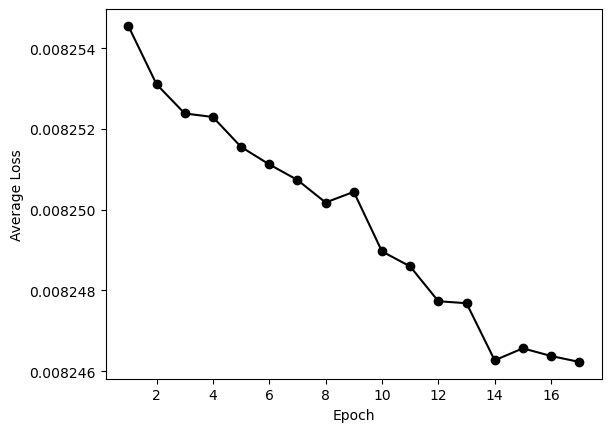

In [83]:
# Plotting,
epochs = np.arange(start=1, stop=len(train_losses)+1, step=1)
plt.plot(epochs, train_losses, marker="o", color="black")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.show()